In [1]:
import vcf
import sys
import pandas as pd
import math
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import numpy as np

<h2>Figure 1a</h2>

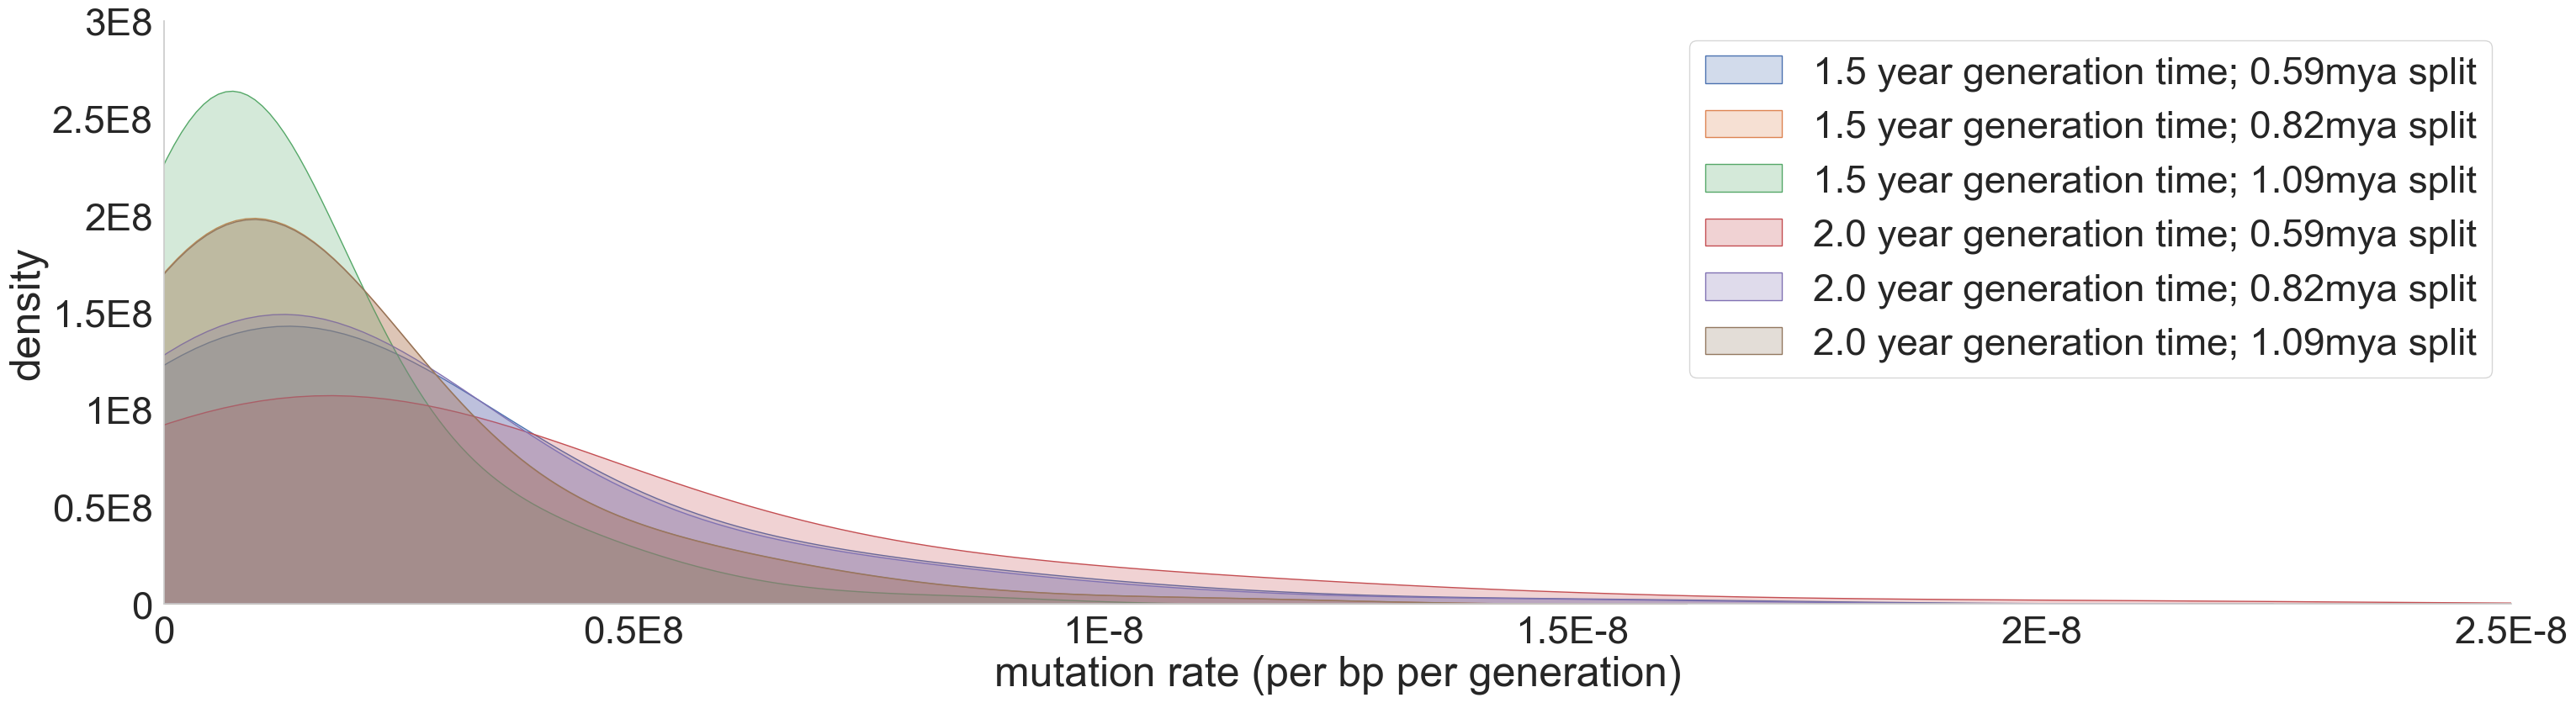

In [2]:
#set generation and divergence times
g1 = 1.5
g2 = 2
d1 = 590000
d2 = 820000
d3 = 1090000
#Read in divergence data
df1 = pd.read_csv(r"/Volumes/WD/chimerism/marmoset_divergence/gaps/kuhlii/100kb_divergence.bed", sep='\t', names=['chrom','start','end','length','point_muts', 'divergence'])
#Subset to X chromosome
df1 = df1[df1.chrom=="NC_071464.1"]
#Limit to windows with atleast 1000 accessible sites
df1 = df1[df1.length>1000]
#Calculate divergence
df1['mu1'] = df1.divergence / (d1/g1)
df1['mu2'] = df1.divergence / (d2/g1)
df1['mu3'] = df1.divergence / (d3/g1)
df1['mu4'] = df1.divergence / (d1/g2)
df1['mu5'] = df1.divergence / (d2/g2)
df1['mu6'] = df1.divergence / (d3/g2)

#Plot density plots
sns.set(rc={'figure.figsize':(36,9),'axes.facecolor':'white','axes.edgecolor': '.8'},font_scale=3)

sns.kdeplot(np.array(df1['mu1']), fill=True, bw_method=0.75, label='1.5 year generation time; 0.59mya split')
sns.kdeplot(np.array(df1['mu2']), fill=True, bw_method=0.75, label='1.5 year generation time; 0.82mya split')
sns.kdeplot(np.array(df1['mu3']), fill=True, bw_method=0.75, label='1.5 year generation time; 1.09mya split')
sns.kdeplot(np.array(df1['mu4']), fill=True, bw_method=0.75, label='2.0 year generation time; 0.59mya split')
sns.kdeplot(np.array(df1['mu5']), fill=True, bw_method=0.75, label='2.0 year generation time; 0.82mya split')
sns.kdeplot(np.array(df1['mu6']), fill=True, bw_method=0.75, label='2.0 year generation time; 1.09mya split')
plt.xlabel('mutation rate (per bp per generation)')
plt.ylabel('density')
plt.legend(bbox_to_anchor=(1, 1))
plt.xlim([0,0.5e-7])
plt.xticks([0, 0.5e-8, 1e-8, 1.5e-8, 2e-8, 2.5e-8], ['0', '0.5E8', '1E-8', '1.5E-8', '2E-8', '2.5E-8'])
plt.yticks([0, 0.5e8, 1e8, 1.5e8, 2e8, 2.5e8, 3e8], ['0', '0.5E8', '1E8', '1.5E8', '2E8', '2.5E8', '3E8'])
plt.xlim([0, 2.5e-8])
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig('/Volumes/WD/chimerism/marmoset_X/plots/fig1a.pdf', format='pdf', bbox_inches='tight')
plt.savefig('/Volumes/WD/chimerism/marmoset_X/plots/fig1a.png', format='png', bbox_inches='tight')

<h2>Figure 1b</h2>

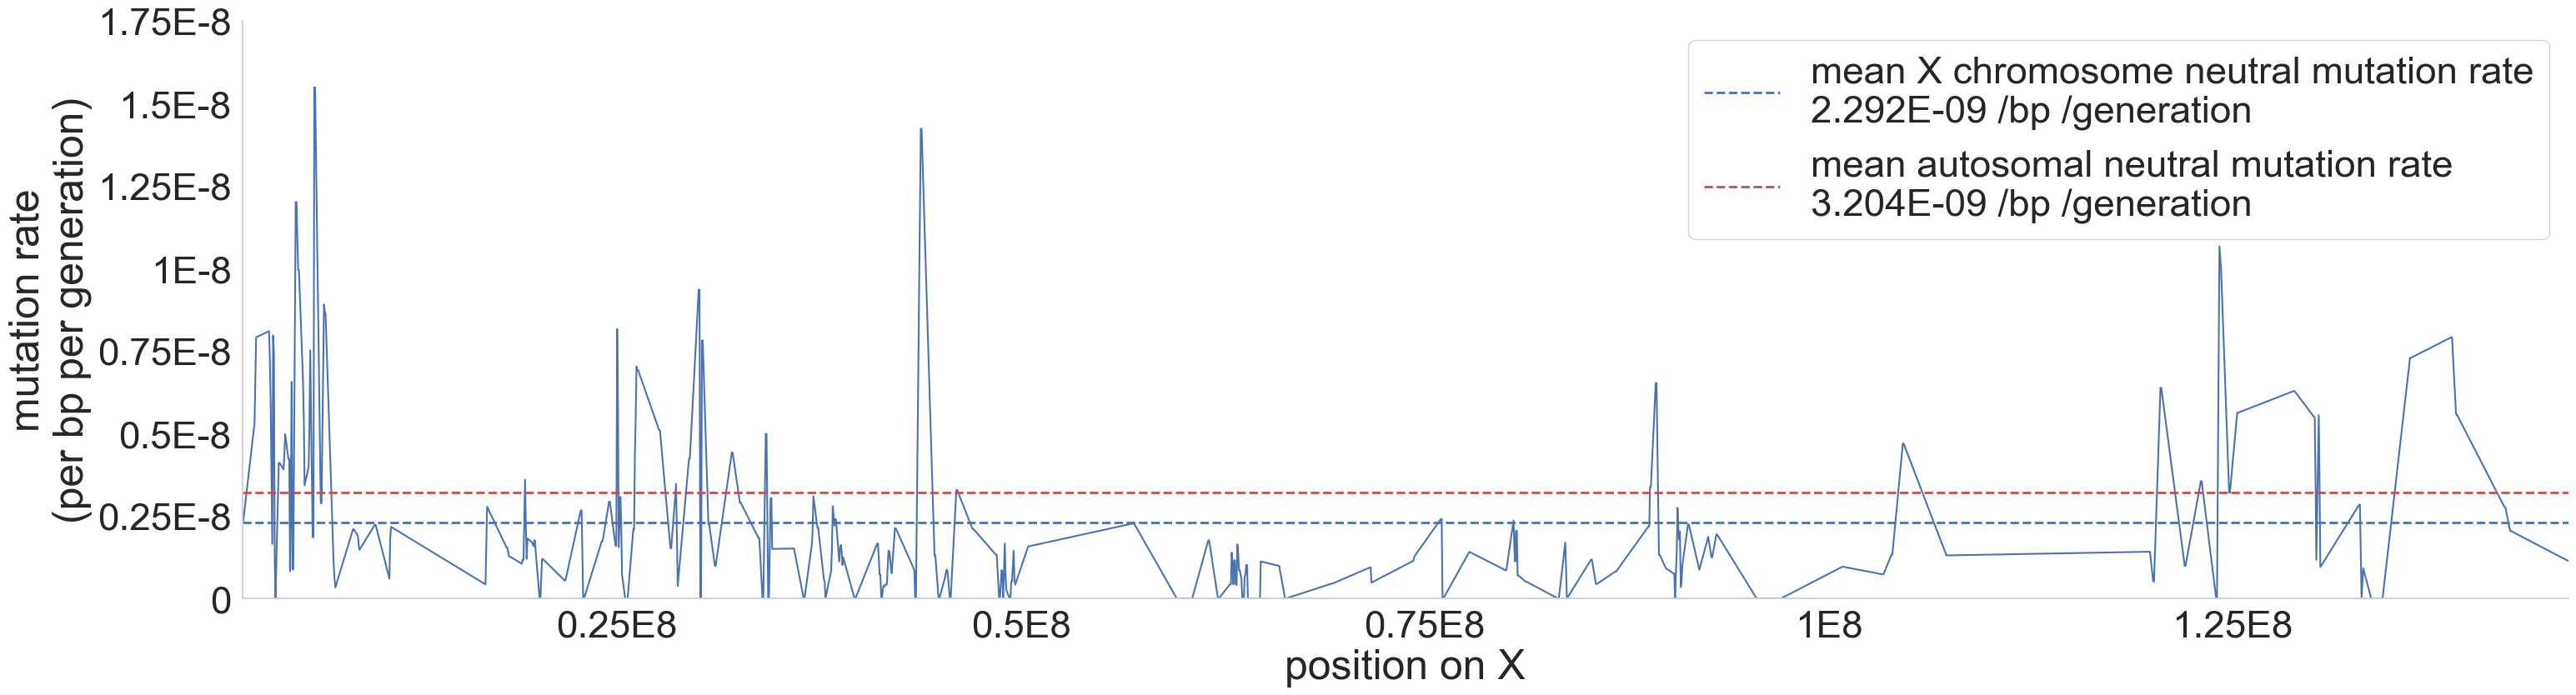

In [3]:
#set generation and divergence times
g1 = 1.5
g2 = 2
d1 = 590000
d2 = 820000
d3 = 1090000
#Read in divergence data. Limit to X chromosome
xdf = pd.read_csv(r"/Volumes/WD/chimerism/marmoset_divergence/gaps/kuhlii/100kb_divergence.bed", sep='\t', names=['chrom','start','end','length','point_muts', 'divergence'])
xdf = xdf[xdf.chrom=="NC_071464.1"]
xdf = xdf[xdf.length>1000]
xdf['mu'] = xdf.divergence / (d2/g2)
#Limit to autosomes for comparison
adf = pd.read_csv(r"/Volumes/WD/chimerism/marmoset_divergence/gaps/kuhlii/100kb_divergence.bed", sep='\t', names=['chrom','start','end','length','point_muts', 'divergence'])
adf = adf[adf.chrom!="NC_071464.1"]
adf = adf[adf.length>1000]
adf['mu'] = adf.divergence / (d2/g2)

sns.set(rc={'figure.figsize':(36,9),'axes.facecolor':'white','axes.edgecolor': '.8'},font_scale=3)
plt.plot(xdf.start, xdf.mu, color='b')
plt.xticks([0, 0.25e8, 0.5e8, 0.75e8, 1e8, 1.25e8, 1.5e8], ['0', '0.25E8', '0.5E8', '0.75E8', '1E8', '1.25E8', '1.5E8'])
plt.ylim([0, 1.75e-8])
plt.yticks([0, 0.25e-8, 0.5e-8, 0.75e-8, 1e-8, 1.25e-8, 1.5e-8, 1.75e-8], ['0', '0.25E-8', '0.5E-8', '0.75E-8', '1E-8', '1.25E-8', '1.5E-8', '1.75E-8'])
plt.axhline(xdf.mu.mean(), linestyle='--', color='b', label=f'mean X chromosome neutral mutation rate\n{xdf.mu.mean():.3E} /bp /generation', lw=2)
plt.axhline(adf.mu.mean(), linestyle='--', color='r', label=f'mean autosomal neutral mutation rate\n{adf.mu.mean():.3E} /bp /generation', lw=2)
plt.margins(0)
plt.ylabel('mutation rate\n(per bp per generation)')
plt.xlabel('position on X')
plt.legend()
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig('/Volumes/WD/chimerism/marmoset_X/plots/fig1b.pdf', format='pdf', dpi=350, bbox_inches='tight')
plt.savefig('/Volumes/WD/chimerism/marmoset_X/plots/fig1b.png', format='png', dpi=350, bbox_inches='tight')

<h2>Figure 2</h2>

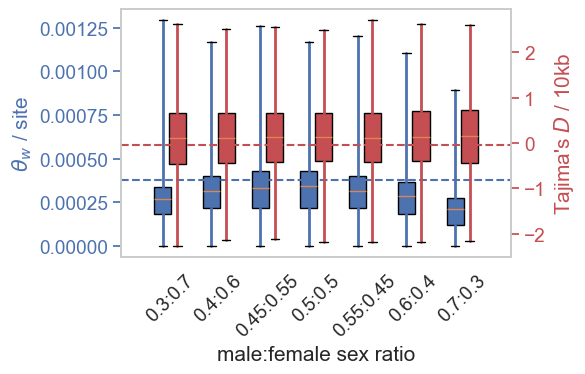

In [4]:
#Read in empirical summary statistics
rdf = pd.read_csv(r"/Volumes/WD/chimerism/marmoset_X/empirical_data/demog_stats.txt", header=0, sep='\t')
#Get means and stds for theta_w and tajimas_d
names = []
lst = []
for i in ['thetaw', 'tajimasd']:
    lst.append(rdf[i].mean(skipna=True))
    lst.append(rdf[i].std(skipna=True))
    names.append(i + "_m")
    names.append(i + "_std")

xedf = pd.DataFrame(lst).T
xedf.columns = names

#Read in simulated data for each sex ratio
theta_l = []
tajd_l = []
for sr in [0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7]:
    rdf = pd.DataFrame()
    for i in range(1, 101):
        try:
            #Load in stats for given replicate and concatenate with rdf
            df = pd.read_csv(f"/Volumes/WD/chimerism/marmoset_X/demog/{sr}_rep{i}_chimeric.stats", sep='\t', header=0)
            for stat in ['nhaps', 'numexternalmutations', 'numpoly', 'numsingletons', 'thetah', 'thetal', 'thetapi', 'thetaw']:
                df[stat] = df[stat] / 10000
            df['sex_ratio'] = sr
            rdf = pd.concat([rdf,df])
        except Exception:
            pass
    theta_l.append(list(rdf['thetaw']))
    tajd_l.append(list(rdf['tajimasd']))

df = pd.DataFrame(theta_l).T
theta_df = df.describe()
df = pd.DataFrame(tajd_l).T
tajd_df = df.describe()

labels = ['0.3', '0.4', '0.45', '0.5', '0.55', '0.6', '0.7']

# create dictionaries for each column as items of a list
bxp_stats = theta_df.apply(lambda x: {'med':x['mean'], 'q1':x['25%'], 'q3':x['75%'], 'whislo':x['min'], 'whishi':x['max']}, axis=0).tolist()

# add the column names as labels to each dictionary entry
for index, item in enumerate(bxp_stats):
    item.update({'label':labels[index]})

sns.set(rc={'figure.figsize':(6,4),'axes.facecolor':'white','axes.edgecolor': '.8'},font_scale=1.25) 
fig, ax = plt.subplots() # Creates a figure and a single axes

nb_groups = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
ax.bxp(bxp_stats, positions=[x-0.015 for x in nb_groups], showfliers=False, patch_artist=True, widths=0.035, boxprops={'facecolor': 'b'}, whiskerprops=dict(color='b', linewidth=2));
ax.set_ylabel(r'$\theta_w$ / site', color='b')
ax.tick_params(axis='y', colors='b')
#ax.set_ylim([0, 0.0005])


ax2 = ax.twinx()
# create dictionaries for each column as items of a list
bxp_stats = tajd_df.apply(lambda x: {'med':x['mean'], 'q1':x['25%'], 'q3':x['75%'], 'whislo':x['min'], 'whishi':x['max']}, axis=0).tolist()

# add the column names as labels to each dictionary entry
for index, item in enumerate(bxp_stats):
    item.update({'label':labels[index]})
ax2.bxp(bxp_stats, positions=[x+0.015 for x in nb_groups], showfliers=False, widths=0.035, patch_artist=True, boxprops={'facecolor': 'r'}, whiskerprops=dict(color='r', linewidth=2));

ax2.set_ylabel(r"Tajima's $D$ / 10kb", color='r')
ax2.tick_params(axis='y', colors='r')
ax.set_xlim([0.2, 1])
ax.set_xticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
ax.set_xticklabels(['0.3:0.7', '0.4:0.6', '0.45:0.55', '0.5:0.5', '0.55:0.45', '0.6:0.4', '0.7:0.3'], rotation=45)
ax.set_xlabel('male:female sex ratio')
ax.axhline(y=xedf['thetaw_m'][0], linestyle='--', color='b')
ax2.axhline(y=xedf['tajimasd_m'][0], linestyle='--', color='r')
ax.grid(False)
ax2.grid(False)
plt.tight_layout() 
plt.savefig('/Volumes/WD/chimerism/marmoset_X/plots/fig2.pdf', dpi=350, format='pdf', bbox_inches='tight', )
plt.savefig('/Volumes/WD/chimerism/marmoset_X/plots/fig2.png', dpi=350, format='png', bbox_inches='tight')

<h2>Figure 3</h2>

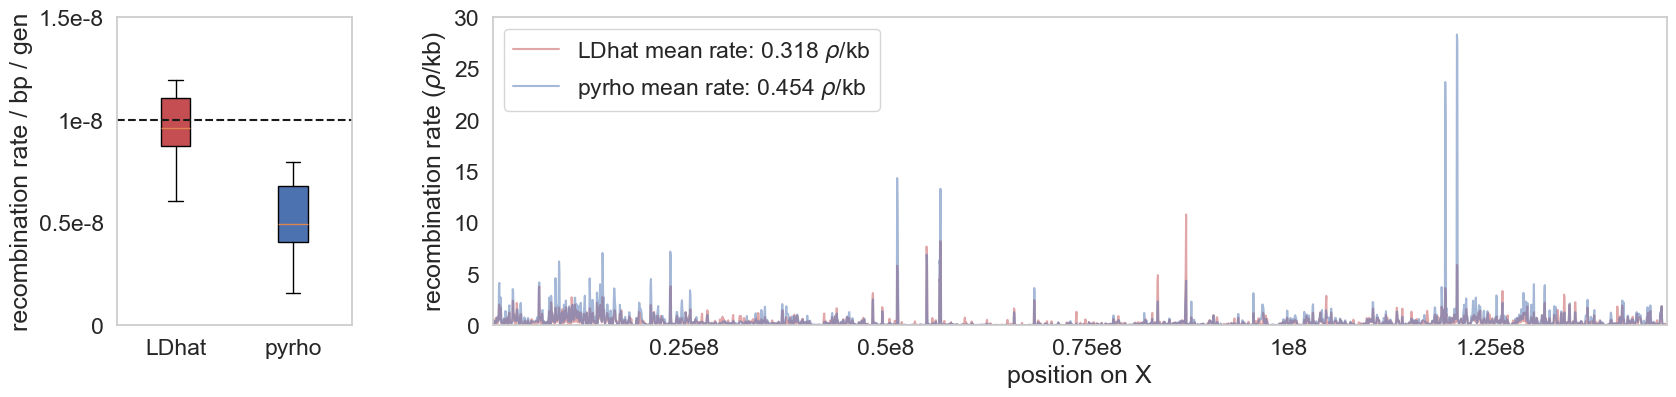

In [5]:
#Calculate Ne from mutation rate and simulated theta_w
mu = 0.229e-8
theta = 0.0003
Ne= theta / (3 * mu)
lst = []
lst2 =[]
#Loop through LDhat and pyrho simulation inference results, storing mean values to lists
for i in range(1, 11):
    df = pd.read_csv("/Volumes/WD/chimerism/marmoset_X/rec_sims/LDhat/results/rep"+str(i)+"_res.txt", sep='\t', header=0).iloc[1:]
    # LDhat estimates in 4Ne r / kb. Therefore, multiple by 1000 to get units in Mb, and by another 100 to go from M to cM, then divide by 4Ne
    df['r'] = (df.Mean_rho / 1000) /(3*Ne)
    lst.append(df.r.mean())

    df2 = pd.read_csv("/Volumes/WD/chimerism/marmoset_X/rec_sims/pyrho/rep"+str(i)+".rmap", sep='\t', names=['start', 'end', 'r'])
    # LDhat estimates in 4Ne r / kb. Therefore, multiple by 1000 to get units in Mb, and by another 100 to go from M to cM, then divide by 4Ne
    lst2.append(df2.r.mean())
df = pd.DataFrame([lst, lst2]).T
df.columns=['LDhat', 'pyrho']
#Get mean values (used later for rescaling)
lh = df.mean().iloc[0]
py = df.mean().iloc[1]
#Plot LDhat and pyrho inference results (Figure 3a)
df2 = df.describe()
labels = ['LDhat', 'pyrho']
# create dictionaries for each column as items of a list
bxp_stats = df2.apply(lambda x: {'med':x['mean'], 'q1':x['25%'], 'q3':x['75%'], 'whislo':x['min'], 'whishi':x['max']}, axis=0).tolist()

# add the column names as labels to each dictionary entry
for index, item in enumerate(bxp_stats):
    item.update({'label':labels[index]})

sns.set(rc={'figure.figsize':(30, 4),'axes.facecolor':'white','axes.edgecolor': '.8'},font_scale=1.5)
fig, axs = plt.subplots(1, 2, gridspec_kw={'width_ratios': [1, 5]}, figsize=(20, 4))

bp = axs[0].bxp(bxp_stats, showfliers=False, patch_artist=True, widths=0.25);
# Iterate through the boxes and set their facecolor
colors = ['r', 'b']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

axs[0].set_ylabel(r'recombination rate / bp / gen')
axs[0].set_yticks([0, 0.5e-8, 1e-8, 1.5e-8, 2e-8, 2.5e-8])
axs[0].set_yticklabels(['0', '0.5e-8', '1e-8', '1.5e-8', '2e-8', '2.5e-8'])

axs[0].set_ylim([0, 1.5e-8])
axs[0].axhline(y=1e-8, linestyle='--', color='k')

#Calculate Ne from mutation rate and empirical theta_w
mu = 0.229e-8
theta = 0.0005
Ne= theta / (3 * mu)

df = pd.read_csv(r"/Volumes/WD/chimerism/marmoset_X/empirical_data/rec/LDhat/100kb_rho.bed", sep='\t', names=['chrom', 'start', 'end', 'rho'])
# LDhat estimates in 4Ne r / kb. Therefore, multiple by 1000 to get units in Mb, and by another 100 to go from M to cM, then divide by 4Ne
df = df[df.start>1210000]
#Scale rec by extent of simulation misinference
df['rho'] = df['rho'] / (lh/1e-8)

df2 = pd.read_csv(r"/Volumes/WD/chimerism/marmoset_X/empirical_data/rec/pyrho/2_100kb_r.bed", sep='\t', names=['chrom', 'start', 'end', 'r'])
# pyrho estimates in r / bp. Therefore, multiple by 1,000,000 to get units in Mb, and by another 100 to go from M to cM
df2 = df2[df2.start>1210000]
#df2['r'] = (df2.rho * 1000000 * 100) 
df2['rho'] = df2['r'] * 1000 * (3*Ne)
df2['rho'] = df2['rho'] / (py/1e-8)

axs[1].plot(df['start'], df['rho'], color='r', label=f'LDhat mean rate: {df.rho.mean():.3f} ' +  r'$\rho$/kb', alpha=0.5)
axs[1].plot(df2['start'], df2['rho'], color='b', label=f'pyrho mean rate: {df2.rho.mean():.3f} ' +  r'$\rho$/kb', alpha=0.5)
# plt.axhline(df.r.mean(), linestyle='--', color='r', label='LDhat mean rate: 0.167 cM/Mb', lw=2)
# plt.axhline(df2.r.mean(), linestyle='--', color='b', label='Pyrho mean rate: 0.043 cM/Mb', lw=2)
axs[1].set_xticks([0, 0.25e8, 0.5e8, 0.75e8, 1e8, 1.25e8, 1.5e8]) 
axs[1].set_xticklabels(['0', '0.25e8', '0.5e8', '0.75e8', '1e8', '1.25e8', '1.5e8'])
axs[1].set_xlim([1210000,  146897247])
#plt.yticks([0, 1e-8, 2e-8, 3e-8, 4e-8, 5e-8], ['0', '1e-8', '2e-8', '3e-8', '4e-8', '5e-8'])
axs[1].set_ylabel(r'recombination rate ($\rho$/kb)')
axs[1].set_xlabel('position on X')
axs[1].legend()
axs[1].set_ylim([0, 30])
axs[1].margins(0)

plt.savefig('/Volumes/WD/chimerism/marmoset_X/plots/fig3.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.savefig('/Volumes/WD/chimerism/marmoset_X/plots/fig3.png', format='png', bbox_inches='tight', dpi=300)

<h2>Figure 4</h2>

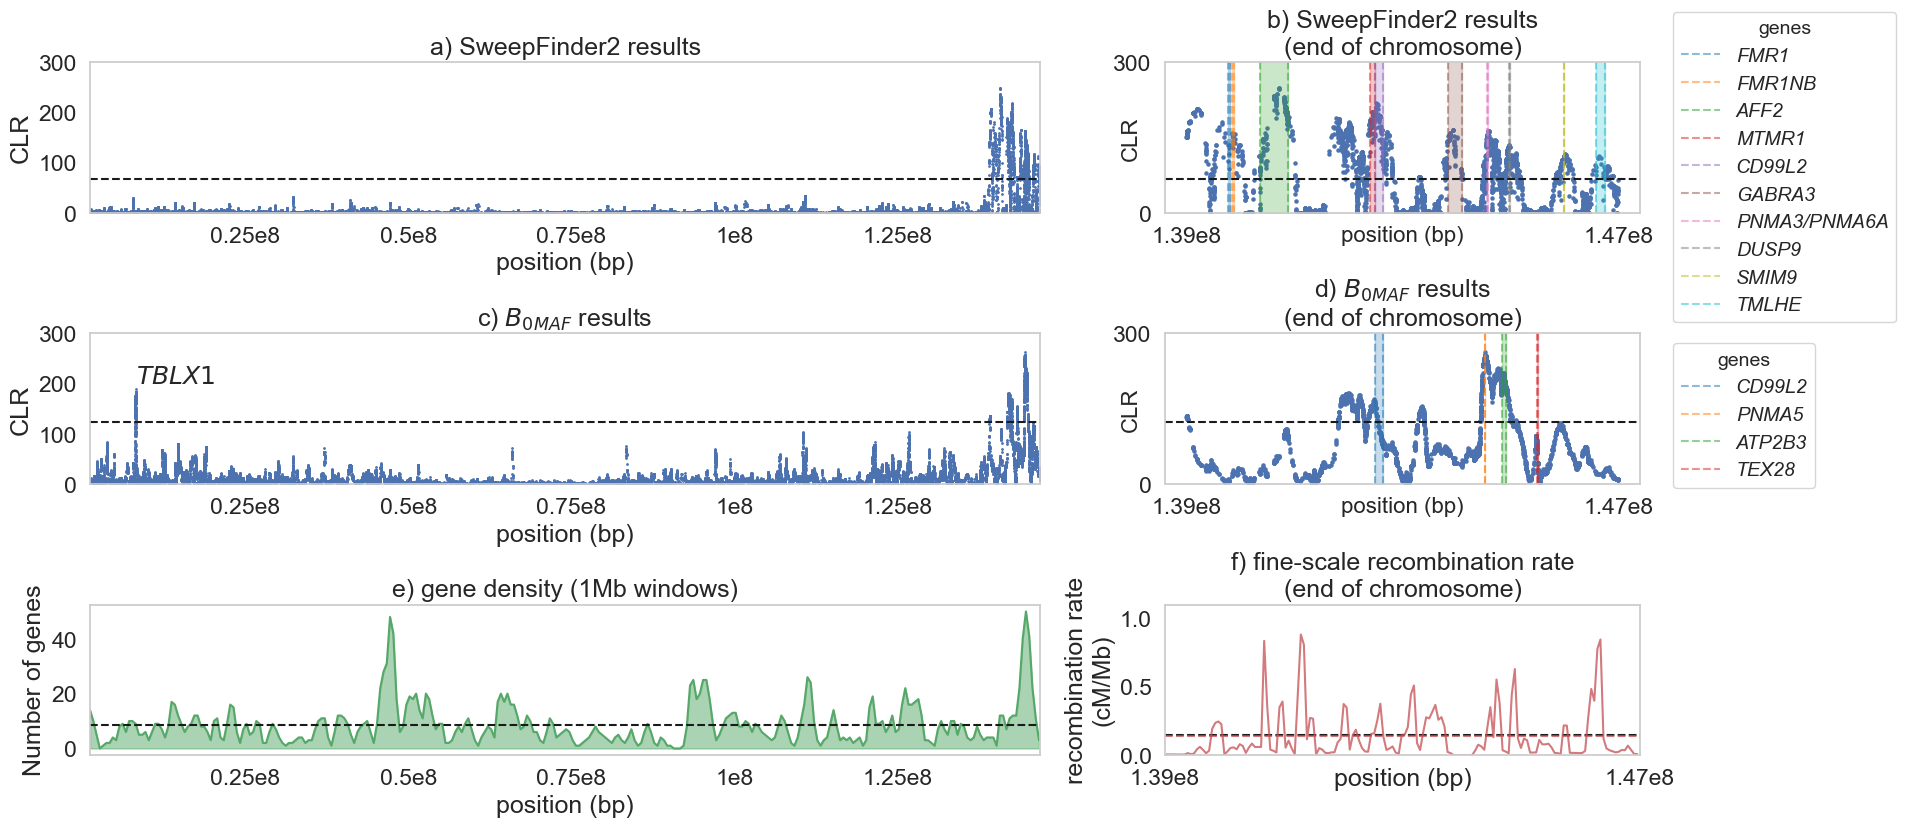

In [6]:
#Set thresholds for SF2 and B0MAF inference (based on null threshold simulation inference)
maxes = {'sf': 67.401839, 'bm': 122.77873756182544}

cols = ['tab:blue',
        'tab:orange',
'tab:green',
'tab:red',
'tab:purple',
'tab:brown',
'tab:pink',
'tab:gray',
'tab:olive',
'tab:cyan']
#Load in empirical SF2 and BM inference results
df = pd.read_csv(r"/Volumes/WD/chimerism/marmoset_X/sweep_scans/empirical/X_SF2.out", sep='\t', header=0)
df2 = pd.read_csv(r"/Volumes/WD/chimerism/marmoset_X/sweep_scans/empirical/X_BM_all.out", sep='\t', header=0)

#Set figure dimensions
sns.set(rc={'figure.figsize':(30, 18),'axes.facecolor':'white','axes.edgecolor': '.8'},font_scale=1.5)
fig, axs = plt.subplots(3, 2, gridspec_kw={'width_ratios': [3, 1.5]}, figsize=(20, 9))
#Plot SF2 scan results
axs[0,0].scatter(df.location, df.LR, s=1)
#Horizontal line for null threshold
axs[0,0].axhline(maxes['sf'], linestyle='--', color='k')
axs[0,0].set_ylabel('CLR')
axs[0,0].tick_params(axis='y')
axs[0,0].set_xticks([0.25e8, 0.5e8, 0.75e8, 1e8, 1.25e8]) 
axs[0,0].set_xticklabels(['0.25e8', '0.5e8', '0.75e8', '1e8', '1.25e8'])
axs[0,0].set_xlabel('position (bp)')
axs[0,0].margins(0)
axs[0,0].grid(False)
axs[0,0].set_ylim([-0.0001, 300])
axs[0,0].set_yticks([0, 100, 200, 300])
axs[0,0].set_title('a) SweepFinder2 results')

#Load in candidate gene information
gdf = pd.read_csv(r"/Volumes/WD/chimerism/marmoset_X/sweep_scans/empirical/X_SF2_genes.out", sep='\t', 
                 names=['chrom','start','end','gene','CLR'])
gdf = gdf[~gdf.gene.str.contains("LOC")]
#Create list of genes to plot
gene_names = ['FMR1', 'FMR1NB', 'AFF2', 'MTMR1', 'CD99L2', 'GABRA3', 'PNMA3/PNMA6A', 'DUSP9', 'SMIM9', 'TMLHE']
genes = ['FMR1', 'FMR1NB', 'AFF2', 'MTMR1', 'CD99L2', 'GABRA3', 'PNMA3', 'DUSP9', 'SMIM9', 'TMLHE']
df1 = df[df.location>=139126345]
#Plot candidate genes in far right of chromosome
axs[0,1].scatter(x=df1.location, y=df1['LR'], s=5)
for x,g in enumerate(genes):
    tdf = gdf[gdf.gene==g]
    tdf = tdf[tdf.start==tdf.start.max()]
    axs[0,1].axvline(tdf.start.min(), color=cols[x], linestyle='--', alpha=0.5, label=gene_names[x])
    axs[0,1].axvline(tdf.end.max(), color=cols[x], linestyle='--', alpha=0.5)
    axs[0,1].fill_betweenx([0, 600], [tdf.start.min()], [tdf.end.max()],
                  alpha=0.25, color=cols[x])
axs[0,1].set_ylim([0, 300])
legend = axs[0,1].legend(title='genes', prop={'size': 14}, title_fontsize=14, bbox_to_anchor=(1.05,1.4))
axs[0,1].set_yticks([0, 300])
axs[0,1].set_xticks([139126345, 146897247])
axs[0,1].set_xticklabels(['1.39e8', '1.47e8'])
axs[0,1].set_xlabel('position (bp)', size=16, labelpad=-15)
axs[0,1].set_ylabel('CLR', size=16, labelpad=-20)
axs[0,1].axhline(maxes['sf'], linestyle='--', color='k')
axs[0,1].set_title(f'b) SweepFinder2 results\n(end of chromosome)')
for text in legend.get_texts():
    text.set_fontstyle("italic")

#Repeat but for balancing selection scans and genes
axs[1,0].scatter(df2.physPos, df2.CLR, s=1)
axs[1,0].axhline(maxes['bm'], linestyle='--', color='k')
axs[1,0].set_ylabel('CLR')
axs[1,0].set_xticks([0.25e8, 0.5e8, 0.75e8, 1e8, 1.25e8]) 
axs[1,0].set_xticklabels(['0.25e8', '0.5e8', '0.75e8', '1e8', '1.25e8'])
axs[1,0].set_xlabel('position (bp)')
axs[1,0].grid(False)
axs[1,0].margins(0)
axs[1,0].set_yticks([0, 100, 200, 300])
axs[1,0].set_ylim([-0.0001, 300])
axs[1,0].set_title(r'c) $B_{0MAF}$ results')


gdf = pd.read_csv(r"/Volumes/WD/chimerism/marmoset_X/sweep_scans/empirical/X_BM_genes.out", sep='\t', 
                 names=['chrom','start','end','gene','CLR'])
gdf = gdf[~gdf.gene.str.contains("LOC")]
gdf = gdf[gdf.start>139126345]
genes = list(gdf.gene)
df1 = df2[df2.physPos>139126345]
axs[1,1].scatter(x=df1.physPos, y=df1['CLR'], s=5)
for x,g in enumerate(genes):
    tdf = gdf[gdf.gene==g]
    tdf = tdf[tdf.start==tdf.start.max()]
    axs[1,1].axvline(tdf.start.min(), color=cols[x], linestyle='--', alpha=0.5, label=g)
    axs[1,1].axvline(tdf.end.max(), color=cols[x], linestyle='--', alpha=0.5)
    axs[1,1].fill_betweenx([0, 600], [tdf.start.min()], [tdf.end.max()],
                  alpha=0.25, color=cols[x])
axs[1,1].set_ylim([0, 100])
legend = axs[1,1].legend(title='genes', prop={'size': 14}, title_fontsize=14, bbox_to_anchor=(1.05,1))
axs[1,1].set_yticks([0, 300])
axs[1,1].set_xticks([139126345, 146897247])
axs[1,1].set_xticklabels(['1.39e8', '1.47e8'])
axs[1,1].set_xlabel('position (bp)', size=16, labelpad=-15)
axs[1,1].set_ylabel('CLR', size=16, labelpad=-20)
axs[1,1].axhline(maxes['bm'], linestyle='--', color='k')
axs[1,1].set_title(r'd) $B_{0MAF}$ results' + '\n' + '(end of chromosome)')

for text in legend.get_texts():
    text.set_fontstyle("italic")

#Plot gene density
df = pd.read_csv(r"/Volumes/WD/chimerism/marmoset_X/sweep_scans/empirical/1mb_gene.counts.bed", sep='\t', names=["chrom", "start", "end", "genes"])
axs[2,0].plot(df.start, df.genes, c='g')
axs[2,0].set_xticks([0.25e8, 0.5e8, 0.75e8, 1e8, 1.25e8]) 
axs[2,0].set_xticklabels(['0.25e8', '0.5e8', '0.75e8', '1e8', '1.25e8'])
axs[2,0].set_xlim([1210000,  146897247])
axs[2,0].set_xlabel('position (bp)')
axs[2,0].set_ylabel("Number of genes")
axs[2,0].fill_between(
        x= df.start, 
        y1= df.genes,
        alpha= 0.5, color='g')
axs[2,0].set_title("e) gene density (1Mb windows)")
axs[2,0].axhline(df.genes.mean(), linestyle='--', color='k')


#Plot recombination
#Get recombination rate map
mu = 0.229e-8
theta = 0.0005
Ne= theta / (3 * mu)

df = pd.read_csv(r"/Volumes/WD/chimerism/marmoset_X/empirical_data/rec/LDhat/100kb_rho.bed", sep='\t', names=['chrom', 'start', 'end', 'rho'])
# LDhat estimates in 4Ne r / kb. Therefore, multiple by 1000 to get units in Mb, and by another 100 to go from M to cM, then divide by 4Ne
df = df[df.start>1210000]
df['r'] = (df.rho * 1000 * 100) /(3*Ne)
#Scale recombination (based on simulated rec inference)
df['r'] = df['r'] / (9.597374604777124e-09/1e-8)

axs[2,1].axhline(df.r.mean(), linestyle='--', color='k')
df = df[df.start>139126345]

axs[2,1].plot(df['start'], df['r'], color='r', label=f'LDhat mean rate: {df.r.mean():.3f} cM/Mb', alpha=0.75)
#axs[2,1].set_xticks([0.25e8, 0.5e8, 0.75e8, 1e8, 1.25e8]) 
#axs[2,1].set_xticklabels(['0.25e8', '0.5e8', '0.75e8', '1e8', '1.25e8'])
axs[2,1].set_xlim([139126345,  146897247])
axs[2,1].set_xticks([139126345, 146897247])
axs[2,1].set_xticklabels(['1.39e8', '1.47e8'])
#plt.yticks([0, 1e-8, 2e-8, 3e-8, 4e-8, 5e-8], ['0', '1e-8', '2e-8', '3e-8', '4e-8', '5e-8'])
axs[2,1].set_ylabel('recombination rate\n(cM/Mb)')
axs[2,1].set_xlabel('position (bp)', labelpad=-15)
axs[2,1].set_ylim([0, 1.1])
axs[2,1].set_title(f"f) fine-scale recombination rate\n(end of chromosome)") 
axs[2,1].axhline(df.r.mean(), linestyle='--', color='r', alpha=0.75)
plt.margins(0)

axs[1,0].text(s=r'$TBLX1$', x=8199605, y=200) 

plt.subplots_adjust(wspace=0.175, hspace=0.8)

plt.savefig('/Volumes/WD/chimerism/marmoset_X/plots/fig4.pdf', format='pdf', bbox_inches='tight')
plt.savefig('/Volumes/WD/chimerism/marmoset_X/plots/fig4.png', format='png', bbox_inches='tight')